In [253]:
#Importing libraries
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import sklearn
from sklearn.preprocessing import StandardScaler
import numpy as np

In [254]:
print("scikit-learn:", sklearn.__version__)
print("numpy:", np.__version__)

scikit-learn: 1.8.0
numpy: 2.4.4


In [255]:
#Sets up my df
df = pd.read_csv("../Data/Cleaned_data/Clean.csv")
df = df.set_index("Date_month")
df.index = pd.to_datetime(df.index) #Sets my date index to specifically be date data type
df

,SP500_monthly_return,SP500_volatility,YOY_inflation,Inflation_volatility,Inflation_surprise,SP500_volatility_lag,Inflation_lag,Volatility_lag,Surprise_lag
Date_month,,,,,,,,,
2001-01-01,-2.429990,4.567131,3.721205,0.239086,0.721205,4.760707,3.436019,0.286482,0.636019
2001-02-01,7.028914,5.041273,3.529412,0.229091,0.729412,4.567131,3.721205,0.239086,0.721205
2001-03-01,-9.628168,5.732928,2.982456,0.248253,0.182456,5.041273,3.529412,0.229091,0.729412
2001-04-01,-7.682701,5.115852,3.218256,0.224944,0.118256,5.732928,2.982456,0.248253,0.182456
2001-05-01,10.522131,6.279052,3.563084,0.208416,0.363084,5.115852,3.218256,0.224944,0.118256
...,...,...,...,...,...,...,...,...,...
2025-08-01,0.645368,3.235395,2.938592,0.232003,-1.861408,3.270294,2.742618,0.213919,-1.757382
2025-09-01,2.845944,3.270414,3.022572,0.242695,-1.677428,3.235395,2.938592,0.232003,-1.861408
2025-10-01,4.608500,3.366205,2.858718,0.243175,-1.741282,3.270414,3.022572,0.242695,-1.677428


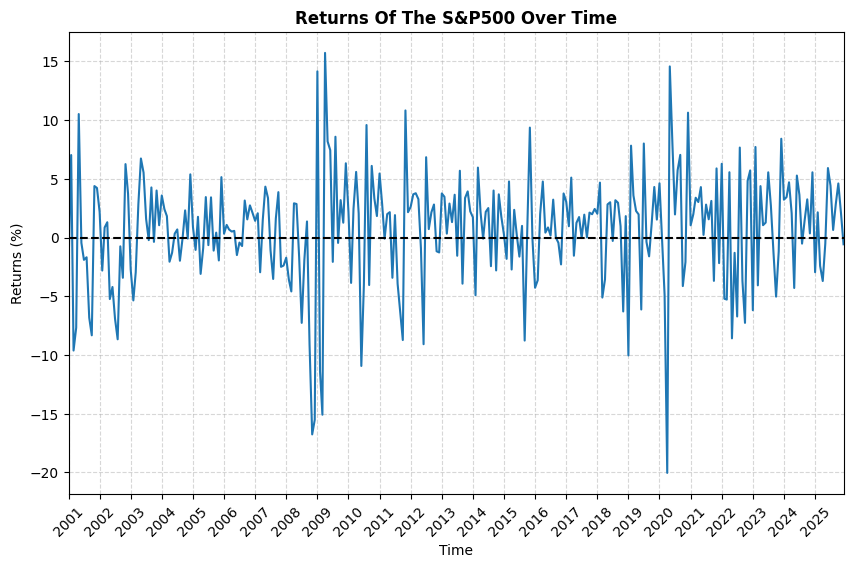

In [256]:
#plots a monthly time series of the S&P500 return from the start of 2001 to the end of 2025
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.SP500_monthly_return)
plt.axhline(0, color="black", linestyle="dashed") #Produces a dotted line at y = 0
plt.xlim(df.index.min(), df.index.max()) #starts and ends the plot at the start and end of my data set (removes space before and after)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) #Sets x axis ticks to be every year
plt.xticks(rotation=45) #rotates dates to be 45 degrees to allow for better readability
plt.title("Returns Of The S&P500 Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Returns (%)")
plt.grid(linestyle="--",alpha=0.5) #Adds a grid to allow for better readability
plt.savefig("../Outputs/figures/sp500_returns_timeseries.png", dpi=300, bbox_inches='tight') #produces a png file of the plot

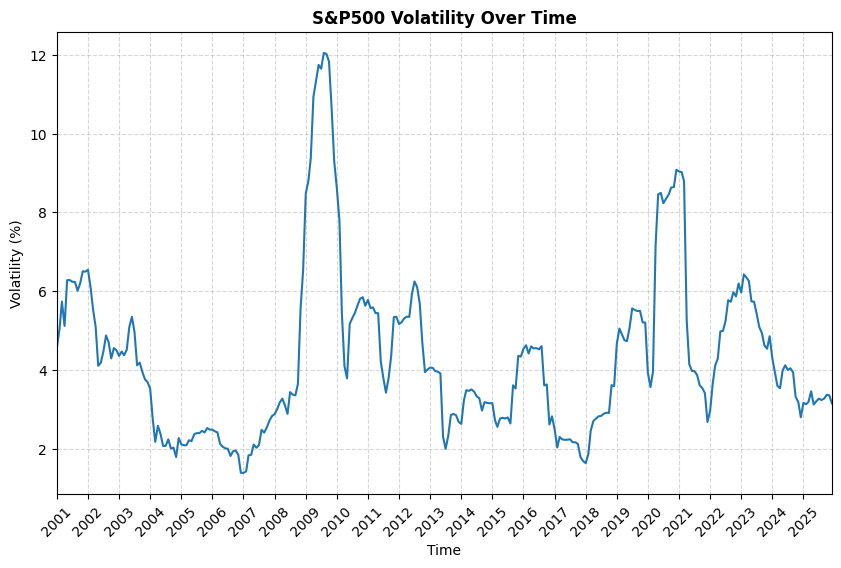

In [257]:
#plots a monthly time series of S&P500 volatility from the start of 2001 to the end of 2025
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.SP500_volatility)
plt.xlim(df.index.min(), df.index.max()) 
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) 
plt.xticks(rotation=45) 
plt.title("S&P500 Volatility Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Volatility (%)")
plt.grid(linestyle="--",alpha=0.5) 
plt.savefig("../Outputs/figures/sp500_volatility_timeseries.png", dpi=300, bbox_inches='tight') 

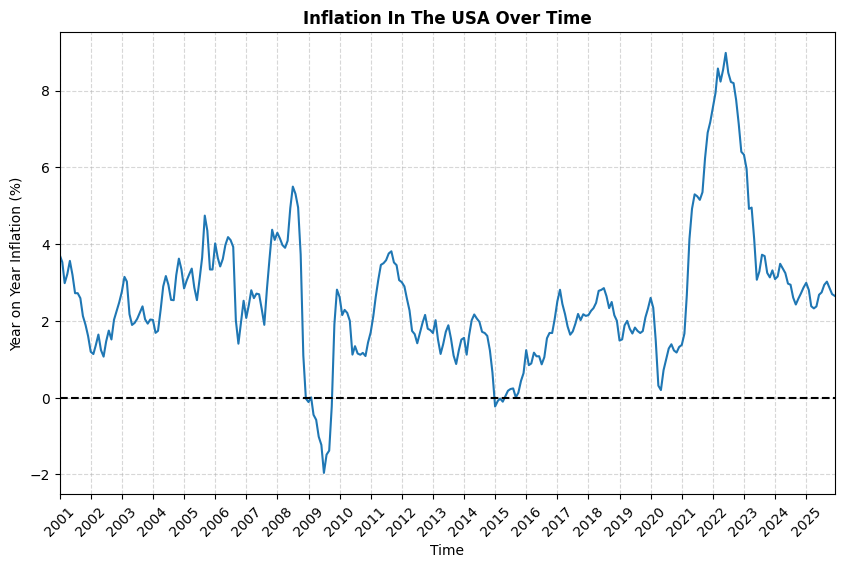

In [258]:
#Time series for inflation
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.YOY_inflation)
plt.axhline(0, color="black", linestyle="dashed")
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Year on Year Inflation (%)")
plt.grid(linestyle="--",alpha=0.5)
plt.savefig("../Outputs/figures/inflation_timeseries.png", dpi=300, bbox_inches='tight')

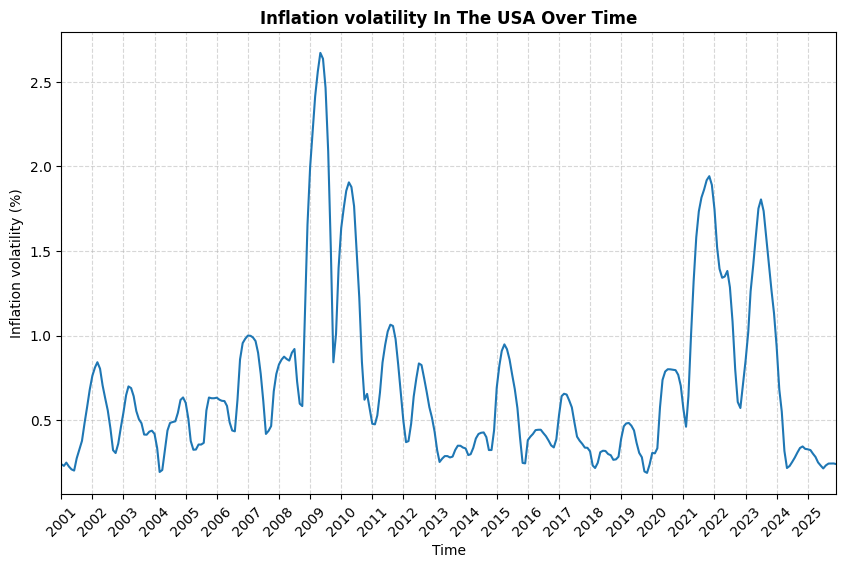

In [259]:
#Time series for inflation volatility
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.Inflation_volatility)
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation volatility In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Inflation volatility (%)")
plt.grid(linestyle="--",alpha=0.5)
plt.savefig("../Outputs/figures/inflation_volatility_timeseries.png", dpi=300, bbox_inches='tight')

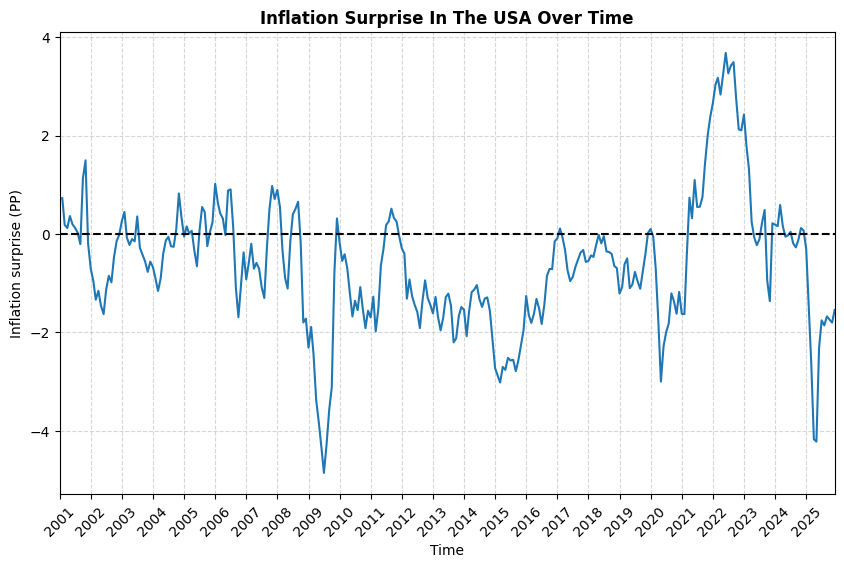

In [260]:
#Time series of inflation surprise over time (the difference between actual inflation and expected inflation)
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.Inflation_surprise)
plt.axhline(0, color="black", linestyle="dashed")
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation Surprise In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Inflation surprise (PP)")
plt.grid(linestyle="--",alpha=0.5)
plt.savefig("../Outputs/figures/inflation_suprise_timeseries.png", dpi=300, bbox_inches='tight')

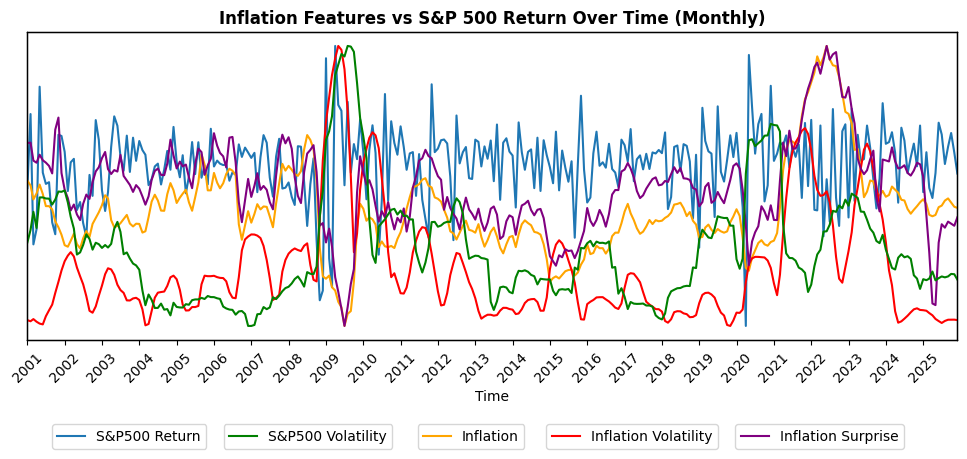

In [31]:
#Time series comparing all previously mentioned components of inflation over time on a monthly basis
plt.figure(figsize=(12,4))
ax1 = sns.lineplot(x=df.index, y=df.SP500_monthly_return, label = "S&P500 Return") #plots S&P500 return over time
ax1.grid(False) #Removes grid lines
ax1.set_ylabel("") #Removes y axis label
ax1.set_yticks([]) #removes y axis ticks since multiple y axis are being used
ax2 = ax1.twinx() # allows me to add another y axis
sns.lineplot(x=df.index, y=df.YOY_inflation, ax=ax2, color="orange", label = "Inflation") #plots inflation level over time
ax2.grid(False)
ax2.set_ylabel("")
ax2.set_yticks([])
ax3 = ax2.twinx()
sns.lineplot(x=df.index, y=df.Inflation_volatility, ax=ax3, color="red", label = "Inflation Volatility") #plots inflation volatility over time
ax3.grid(False)
ax3.set_ylabel("")
ax3.set_yticks([])
ax4 = ax3.twinx()
sns.lineplot(x=df.index, y=df.Inflation_surprise, ax=ax4, color="purple", label = "Inflation Surprise") #plots inflation suprise over time
ax4.grid(False)
ax4.set_ylabel("")
ax4.set_yticks([])
ax5 = ax4.twinx()
sns.lineplot(x=df.index, y=df.SP500_volatility, ax=ax5, color="green", label = "S&P500 Volatility") #plots inflation suprise over time
ax5.grid(False)
ax5.set_ylabel("")
ax5.set_yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) #sets x axis ticks to be yearly
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time")
plt.title("Inflation Features vs S&P 500 Return Over Time (Monthly)", weight="bold")
#positions the legends in specific position:
ax1.legend(bbox_to_anchor=(0.2, -0.25))
ax5.legend(bbox_to_anchor=(0.4, -0.25))
ax2.legend(bbox_to_anchor=(0.542, -0.25))
ax3.legend(bbox_to_anchor=(0.75, -0.25))
ax4.legend(bbox_to_anchor=(0.95, -0.25))
ax1.set_xlim(df.index.min(), df.index.max()) #makes it so no white space is after y axis
plt.savefig("../Outputs/figures/combined_timeseries_monthly.png", dpi=300, bbox_inches='tight')
plt.show()


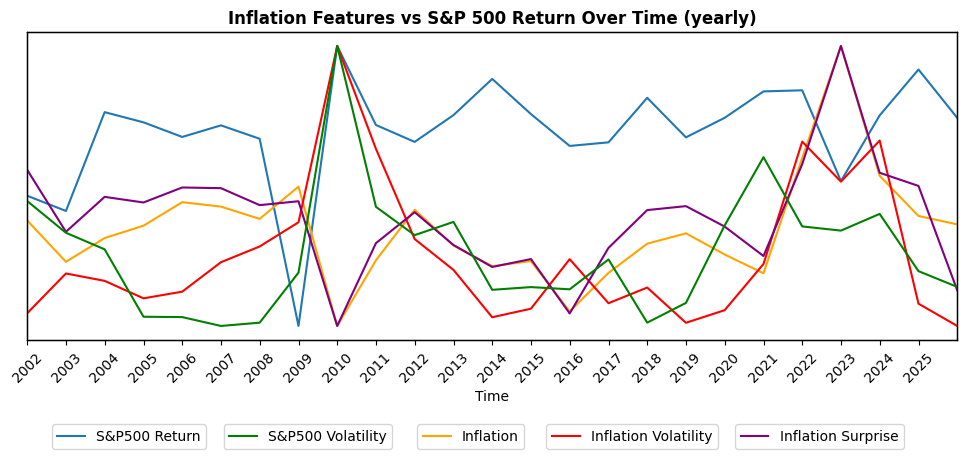

In [ ]:
#Time series comparing all previously mentioned components of inflation over time on a yearly basis
df_yearly = df.resample('YE').mean() #Decided to resample data to yearly data points since monthly values made the graph very cluttered
plt.figure(figsize=(12,4))
ax1 = sns.lineplot(x=df_yearly.index, y=df_yearly.SP500_monthly_return, label = "S&P500 Return")
ax1.grid(False) #removes grid lines
ax1.set_ylabel("") #removes y axis label
ax1.set_yticks([]) #removes y tick names
ax2 = ax1.twinx() #allows me to add another y axis
sns.lineplot(x=df_yearly.index, y=df_yearly.YOY_inflation, ax=ax2, color="orange", label = "Inflation")
ax2.grid(False)
ax2.set_ylabel("")
ax2.set_yticks([])
ax3 = ax2.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.Inflation_volatility, ax=ax3, color="red", label = "Inflation Volatility")
ax3.grid(False)
ax3.set_ylabel("")
ax3.set_yticks([])
ax4 = ax3.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.Inflation_surprise, ax=ax4, color="purple", label = "Inflation Surprise")
ax4.grid(False)
ax4.set_ylabel("")
ax4.set_yticks([])
ax5 = ax4.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.SP500_volatility, ax=ax5, color="green", label = "S&P500 Volatility") #plots inflation suprise over time
ax5.grid(False)
ax5.set_ylabel("")
ax5.set_yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) #changes x axis ticks to every year
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time")
plt.title("Inflation Features vs S&P 500 Return Over Time (yearly)", weight="bold")
#positions the legends in specific position:
ax1.legend(bbox_to_anchor=(0.2, -0.25))
ax5.legend(bbox_to_anchor=(0.4, -0.25))
ax2.legend(bbox_to_anchor=(0.542, -0.25))
ax3.legend(bbox_to_anchor=(0.75, -0.25))
ax4.legend(bbox_to_anchor=(0.95, -0.25))
ax1.set_xlim(df_yearly.index.min(), df_yearly.index.max())
plt.savefig("../Outputs/figures/combined_timeseries_yearly.png", dpi=300, bbox_inches='tight')

plt.show()


P value: 0.23397878475624345
R Value: -0.06892059990226282
R Squared Value: 0.00475004909088779


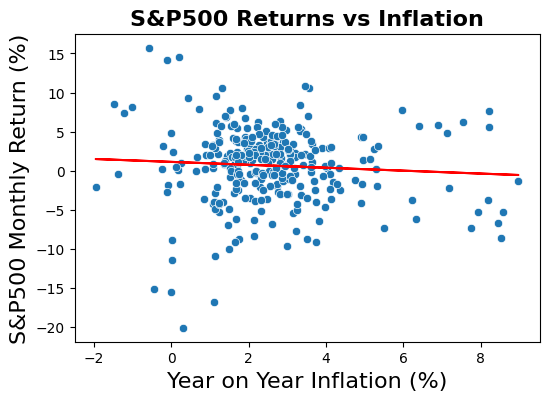

In [263]:
#Plotting S&P500 Return vs Inflation
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.YOY_inflation, y=df.SP500_monthly_return) #plots a scatter plot
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.YOY_inflation, y=df.SP500_monthly_return) #gets useful statistical values
plt.plot(df.YOY_inflation, slope * df.YOY_inflation + intercept, color="red") #plots line of best fit
plt.title("S&P500 Returns vs Inflation", weight="bold", fontsize=16)
plt.xlabel("Year on Year Inflation (%)", fontsize=16)
plt.ylabel("S&P500 Monthly Return (%)", fontsize=16)
plt.savefig("../Outputs/figures/sp500_r_inflation.png", dpi=300, bbox_inches='tight')

#Statistical values:
print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 0.9991787784331346
R Value: 5.967282099866619e-05
R Squared Value: 3.5608455659388564e-09


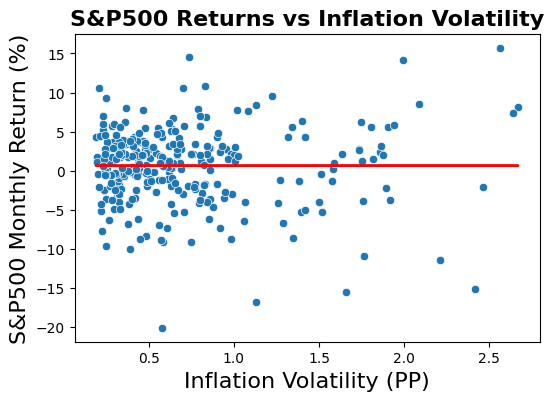

In [264]:
#Plotting S&P500 Return vs Inflation Volatility
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.Inflation_volatility, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_volatility, y=df.SP500_monthly_return)
plt.plot(df.Inflation_volatility, slope * df.Inflation_volatility + intercept, color="red")
plt.title("S&P500 Returns vs Inflation Volatility", weight="bold", fontsize=16)
plt.xlabel("Inflation Volatility (PP)", fontsize=16)
plt.ylabel("S&P500 Monthly Return (%)", fontsize=16)
plt.savefig("../Outputs/figures/sp500_r_inflation_v.png", dpi=300, bbox_inches='tight')

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 0.14448432012952442
R Value: -0.08445433519730161
R Squared Value: 0.007132534733618178


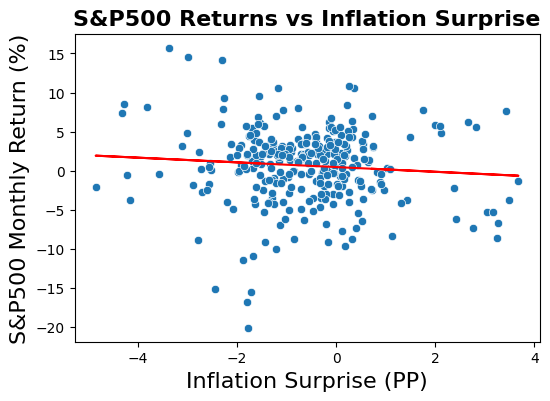

In [265]:
#Plotting S&P500 Return vs Inflation Surprise
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.Inflation_surprise, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_surprise, y=df.SP500_monthly_return)
plt.plot(df.Inflation_surprise, slope * df.Inflation_surprise + intercept, color="red")
plt.title("S&P500 Returns vs Inflation Surprise", weight="bold", fontsize=16)
plt.xlabel("Inflation Surprise (PP)", fontsize=16)
plt.ylabel("S&P500 Monthly Return (%)", fontsize=16)
plt.savefig("../Outputs/figures/sp500_r_inflation_s.png", dpi=300, bbox_inches='tight')

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 7.186488098294385e-06
R Value: -0.25586208702537694
R Squared Value: 0.06546540757698156


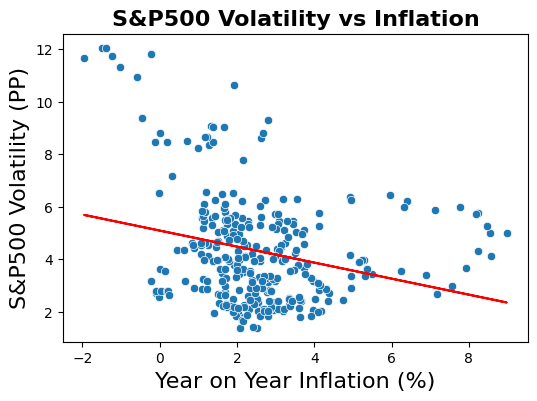

In [266]:
#Plotting S&P500 Volatility vs Inflation
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.YOY_inflation, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.YOY_inflation, y=df.SP500_volatility)
plt.plot(df.YOY_inflation, slope * df.YOY_inflation + intercept, color="red")
plt.title("S&P500 Volatility vs Inflation", weight="bold", fontsize=16)
plt.ylabel("S&P500 Volatility (PP)", fontsize=16)
plt.xlabel("Year on Year Inflation (%)", fontsize=16)
plt.savefig("../Outputs/figures/sp500_v_inflation.png", dpi=300, bbox_inches='tight')

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 5.831009716507495e-17
R Value: 0.4579780013714574
R Squared Value: 0.20974384974019464


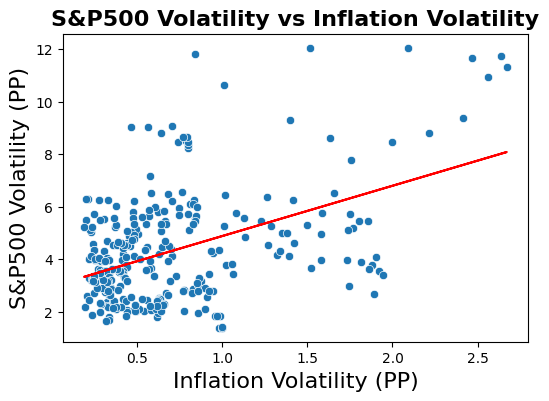

In [267]:
#Plotting S&P500 Volatility vs Inflation Volatility
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.Inflation_volatility, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_volatility, y=df.SP500_volatility)
plt.plot(df.Inflation_volatility, slope * df.Inflation_volatility + intercept, color="red")
plt.title("S&P500 Volatility vs Inflation Volatility", weight="bold", fontsize=16)
plt.ylabel("S&P500 Volatility (PP)", fontsize=16)
plt.xlabel("Inflation Volatility (PP)", fontsize=16)
plt.savefig("../Outputs/figures/sp500_v_inflation_v.png", dpi=300, bbox_inches='tight')

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 2.0287410942608322e-05
R Value: -0.2433565753699523
R Squared Value: 0.05922242277579128


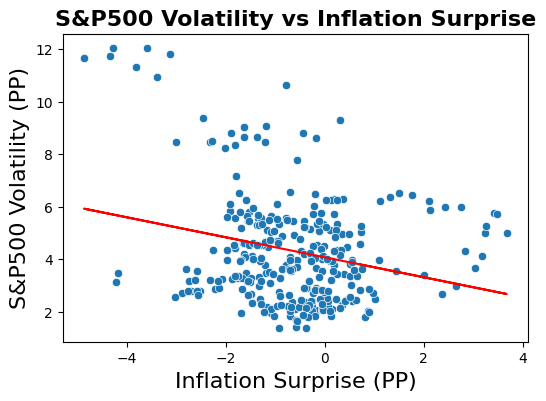

In [268]:
#Plotting S&P500 Volatility vs Inflation Surprise
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.Inflation_surprise, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_surprise, y=df.SP500_volatility)
plt.plot(df.Inflation_surprise, slope * df.Inflation_surprise + intercept, color="red")
plt.title("S&P500 Volatility vs Inflation Surprise", weight="bold", fontsize=16)
plt.ylabel("S&P500 Volatility (PP)", fontsize=16)
plt.xlabel("Inflation Surprise (PP)", fontsize=16)
plt.savefig("../Outputs/figures/sp500_v_inflation_s.png", dpi=300, bbox_inches='tight')

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

In [269]:
#Regression modelling: Regressing sp500 returns on inflation metrics: sp500 returns = a + b1 Inflation + b2 Inflation Volatiltiy + b3 Inflation Surprise + u
x = df[["YOY_inflation", "Inflation_volatility", "Inflation_surprise"]]
y = df["SP500_monthly_return"]
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index) #standardises independent variables to get a comparible output
x_std = sm.add_constant(x_std) #adds y intercept
model1 = sm.OLS(y, x_std).fit(cov_type='HC1') #Runs the regression with robust standard errors since there was heterogeneity in my scatter plots

print(model1.summary2()) #outputs the model sumary
with open("../Outputs/Tables/regression_sp500_r.txt", "w") as f:  #writes the regression table to a new file
    f.write(model1.summary2().as_text())

                   Results: Ordinary least squares
Model:              OLS                  Adj. R-squared:     -0.003   
Dependent Variable: SP500_monthly_return AIC:                1792.2310
Date:               2026-04-27 23:17     BIC:                1807.0461
No. Observations:   300                  Log-Likelihood:     -892.12  
Df Model:           3                    F-statistic:        0.6310   
Df Residuals:       296                  Prob (F-statistic): 0.596    
R-squared:          0.007                Scale:              22.714   
----------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
----------------------------------------------------------------------
const                    0.6648   0.2752  2.4160 0.0157  0.1255 1.2041
YOY_inflation            0.1395   0.6879  0.2027 0.8394 -1.2089 1.4878
Inflation_volatility     0.0022   0.4393  0.0050 0.9960 -0.8589 0.8633
Inflation_surprise      -0

In [270]:
#Regressing sp500 returns on lagged variables to see if current inflation values can predict future sp500 returns
#sp500 returns = a + b1 Lagged Inflation + b2 Lagged Inflation Volatiltiy + b3 Lagged Inflation Surprise + u
x = df[["Inflation_lag", "Volatility_lag", "Surprise_lag"]]
y = df["SP500_monthly_return"]
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index)
x_std = sm.add_constant(x_std)
model2 = sm.OLS(y, x_std).fit(cov_type='HC1')

print(model2.summary2())

with open("../Outputs/Tables/regression_sp500_r_lagged.txt", "w") as f:
    f.write(model2.summary2().as_text())

                   Results: Ordinary least squares
Model:              OLS                  Adj. R-squared:     0.011    
Dependent Variable: SP500_monthly_return AIC:                1788.1551
Date:               2026-04-27 23:17     BIC:                1802.9702
No. Observations:   300                  Log-Likelihood:     -890.08  
Df Model:           3                    F-statistic:        1.511    
Df Residuals:       296                  Prob (F-statistic): 0.212    
R-squared:          0.021                Scale:              22.408   
-----------------------------------------------------------------------
                     Coef.   Std.Err.     z     P>|z|    [0.025  0.975]
-----------------------------------------------------------------------
const                0.6648    0.2733   2.4324  0.0150   0.1291  1.2004
Inflation_lag       -0.4298    0.6587  -0.6525  0.5141  -1.7208  0.8612
Volatility_lag       0.1776    0.4028   0.4408  0.6593  -0.6119  0.9670
Surprise_lag        

In [271]:
#MLR: Regressing sp500 volatility on inflation metrics: sp500 volatility = a + b1 Inflation + b2 Inflation Volatiltiy + b3 Inflation Surprise +b4 Inflation^2 + b5 Inflation Surprise^2 + u
df["Inflation_sqrd"] = df.YOY_inflation**2
df["Surprise_sqrd"] = df.Inflation_surprise**2
x = df[["YOY_inflation", "Inflation_volatility", "Inflation_surprise", "Inflation_sqrd", "Surprise_sqrd"]]
y = df["SP500_volatility"]
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index)

x_std = sm.add_constant(x_std)
model3 = sm.OLS(y, x_std).fit(cov_type='HC1') 

print(model3.summary2())

with open("../Outputs/Tables/regression_sp500_v.txt", "w") as f:
    f.write(model3.summary2().as_text())

                  Results: Ordinary least squares
Model:                OLS              Adj. R-squared:     0.362    
Dependent Variable:   SP500_volatility AIC:                1165.9034
Date:                 2026-04-27 23:17 BIC:                1188.1261
No. Observations:     300              Log-Likelihood:     -576.95  
Df Model:             5                F-statistic:        43.56    
Df Residuals:         294              Prob (F-statistic): 1.56e-33 
R-squared:            0.373            Scale:              2.7973   
--------------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
--------------------------------------------------------------------
const                 4.3058   0.0966 44.5901 0.0000  4.1165  4.4950
YOY_inflation        -1.4905   0.3599 -4.1419 0.0000 -2.1958 -0.7852
Inflation_volatility  0.7870   0.0983  8.0076 0.0000  0.5944  0.9796
Inflation_surprise    0.7924   0.2202  3.5983 0.0003 

In [272]:
#MLR: Regressing sp500 volatility on lagged inflation metrics:
#sp500 returns = a + b1 Lagged Inflation + b2 Lagged Inflation Volatiltiy + b3 Lagged Inflation Surprise + u
x = df[["Inflation_lag", "Volatility_lag", "Surprise_lag"]]
y = df["SP500_volatility"]
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index)

x_std = sm.add_constant(x_std)
model4 = sm.OLS(y, x_std).fit(cov_type='HC1')
print(model4.summary2())
with open("../Outputs/Tables/regression_sp500_v_lag.txt", "w") as f:
    f.write(model4.summary2().as_text())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.301    
Dependent Variable: SP500_volatility AIC:                1191.2940
Date:               2026-04-27 23:17 BIC:                1206.1091
No. Observations:   300              Log-Likelihood:     -591.65  
Df Model:           3                F-statistic:        32.65    
Df Residuals:       296              Prob (F-statistic): 2.93e-18 
R-squared:          0.308            Scale:              3.0644   
------------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------
const               4.3058   0.1011 42.6027 0.0000  4.1077  4.5039
Inflation_lag      -0.7943   0.1815 -4.3768 0.0000 -1.1500 -0.4386
Volatility_lag      1.0451   0.1102  9.4791 0.0000  0.8290  1.2611
Surprise_lag        0.1652   0.1697  0.9736 0.3303 -0.1674  0.4978
-------------

In [273]:
x = df[["YOY_inflation", "Inflation_volatility"]]
y = df["SP500_volatility"]
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index)

x_std = sm.add_constant(x_std)
model5 = sm.OLS(y, x_std).fit(cov_type='HC1') 

print(model5.summary2())

with open("../Outputs/Tables/regression_sp500_v_no_S.txt", "w") as f:
    f.write(model5.summary2().as_text())

                  Results: Ordinary least squares
Model:                OLS              Adj. R-squared:     0.300    
Dependent Variable:   SP500_volatility AIC:                1190.7903
Date:                 2026-04-27 23:17 BIC:                1201.9016
No. Observations:     300              Log-Likelihood:     -592.40  
Df Model:             2                F-statistic:        50.87    
Df Residuals:         297              Prob (F-statistic): 1.00e-19 
R-squared:            0.305            Scale:              3.0694   
--------------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
--------------------------------------------------------------------
const                 4.3058   0.1011 42.5683 0.0000  4.1075  4.5040
YOY_inflation        -0.6478   0.1294 -5.0051 0.0000 -0.9014 -0.3941
Inflation_volatility  1.0285   0.1038  9.9114 0.0000  0.8251  1.2319
-----------------------------------------------------

In [274]:
#used vif to calculate multicolinearity coefficients
x = df[["YOY_inflation", "Inflation_surprise"]]
x = sm.add_constant(x)
vif_df = pd.DataFrame()
vif_df["variable"] = x.columns
vif_df["VIF"] = [variance_inflation_factor(x.values, i) 
                 for i in range(x.shape[1])]

vif_df.to_csv("../Outputs/Tables/VIF.csv")
vif_df

,variable,VIF
0,const,17.906135
1,YOY_inflation,4.778747
2,Inflation_surprise,4.778747


In [275]:
#Running the regression:sp500 volatility = a + b1 Inflation + b2 Inflation Volatility + b3 (Inflation * Inflation volatility)
df["Inflation_x_volatility"] = df.YOY_inflation * df.Inflation_volatility
x = df[["YOY_inflation", "Inflation_volatility", "Inflation_x_volatility"]]
y = df["SP500_volatility"]
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index)

x_std = sm.add_constant(x_std)
model6 = sm.OLS(y, x_std).fit(cov_type='HC1') 

print(model6.summary2())

with open("../Outputs/Tables/regression_sp500_v_interaction.txt", "w") as f:
    f.write(model6.summary2().as_text())

                   Results: Ordinary least squares
Model:                OLS               Adj. R-squared:      0.330    
Dependent Variable:   SP500_volatility  AIC:                 1178.6915
Date:                 2026-04-27 23:17  BIC:                 1193.5067
No. Observations:     300               Log-Likelihood:      -585.35  
Df Model:             3                 F-statistic:         84.91    
Df Residuals:         296               Prob (F-statistic):  1.16e-39 
R-squared:            0.337             Scale:               2.9384   
----------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
----------------------------------------------------------------------
const                   4.3058   0.0990 43.5070 0.0000  4.1118  4.4997
YOY_inflation           0.1390   0.2510  0.5536 0.5798 -0.3530  0.6309
Inflation_volatility    1.3797   0.0999 13.8043 0.0000  1.1838  1.5756
Inflation_x_volatility -0.

In [276]:
#MLR: Regressing sp500 volatility on inflation metrics and previous period volatility: 
#sp500 volatility = a + b1 Sp500 volatility lag + b2 Inflation + b3 Inflation Volatiltiy + b4 Inflation Surprise + u
#This regression accounts for volatility persistence.
x = df[["SP500_volatility_lag", "YOY_inflation", "Inflation_volatility", "Inflation_surprise"]]
y = df["SP500_volatility"]
x_std = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns, index=x.index)

x_std = sm.add_constant(x_std)
model7 = sm.OLS(y, x_std).fit(cov_type='HC1') 

print(model7.summary2())

with open("../Outputs/Tables/regression_sp500_v_volatility_persistence.txt", "w") as f:
    f.write(model7.summary2().as_text())

                  Results: Ordinary least squares
Model:                OLS              Adj. R-squared:     0.938    
Dependent Variable:   SP500_volatility AIC:                467.7166 
Date:                 2026-04-27 23:17 BIC:                486.2355 
No. Observations:     300              Log-Likelihood:     -228.86  
Df Model:             4                F-statistic:        911.2    
Df Residuals:         295              Prob (F-statistic): 1.28e-164
R-squared:            0.938            Scale:              0.27380  
--------------------------------------------------------------------
                      Coef.  Std.Err.    z     P>|z|   [0.025 0.975]
--------------------------------------------------------------------
const                 4.3058   0.0302 142.5255 0.0000  4.2466 4.3650
SP500_volatility_lag  1.9700   0.0451  43.6635 0.0000  1.8815 2.0584
YOY_inflation        -0.0496   0.0633  -0.7845 0.4327 -0.1737 0.0744
Inflation_volatility  0.0710   0.0467   1.5203 0.1284